<a href="https://colab.research.google.com/github/DVGroin/-/blob/main/Station_E_%E2%80%94_City_Heat_Dispatcher_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Station E — City Heat Dispatcher Simulator (v2)
-----------------------------------------------
Offline simulator for a school hackathon station.

Students edit ONLY: student_controller(...)
Then run:
    python city_heat_dispatcher_v2.py

Main idea:
- There is a heat source, thermal storage, and two consumers:
  1) Hospital (critical)
  2) Residential block (regular)
- Weather affects demand with a lag
- Source generation changes over time
- Good control should keep the system stable, protect storage reserve,
  and avoid extreme pump behavior
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple
import math

In [ ]:
# ============================================================
# 1. GLOBAL SETTINGS
# ============================================================

DT_HOURS = 0.25   # 15 minutes
STEPS_PER_DAY = int(24 / DT_HOURS)

# Source / storage / network
SOURCE_MAX_HEAT = 120.0
STORAGE_CAPACITY = 420.0          # kWh thermal
STORAGE_MAX_CHARGE = 60.0         # kW
STORAGE_MAX_DISCHARGE = 80.0      # kW
NETWORK_CAPACITY = 120.0          # kW equivalent transfer limit
MAX_PUMP_SPEED = 1.0

# Consumer priorities
HOSPITAL_PRIORITY_WEIGHT = 1.8
RESIDENTIAL_PRIORITY_WEIGHT = 1.0

# Penalty factors
HOSPITAL_UNMET_FACTOR = 6.0
RESIDENTIAL_UNMET_FACTOR = 2.2
PUMP_OVERUSE_FACTOR = 85.0
STORAGE_DEPLETION_FACTOR = 220.0
STORAGE_EMPTY_STEP_FACTOR = 18.0
OVERHEAT_FACTOR = 0.7

# Reserve threshold: below this, storage is considered dangerously low
STORAGE_RESERVE_KWH = 80.0

# Controller guidance only
SCENARIOS = ["BASE", "COLD_SHIFT", "SOURCE_DROP"]


In [1]:
# ============================================================
# 2. DATA STRUCTURES
# ============================================================

@dataclass
class Inputs:
    hour: float
    scenario_name: str
    step_index: int

    outside_temp: float
    delayed_outside_temp: float

    source_heat_kw: float

    hospital_demand_kw: float
    residential_demand_kw: float
    total_demand_kw: float

    storage_soc_kwh: float

    prev_total_demand_kw: float
    prev_source_heat_kw: float

@dataclass
class Control:
    pump_speed: float                 # 0..1
    source_to_hospital_frac: float    # 0..1
    source_to_residential_frac: float # 0..1
    source_to_storage_frac: float     # 0..1
    storage_to_hospital_frac: float   # 0..1
    storage_to_residential_frac: float# 0..1

@dataclass
class StepResult:
    hospital_delivered_kw: float
    residential_delivered_kw: float
    hospital_unmet_kw: float
    residential_unmet_kw: float
    source_waste_kw: float
    storage_soc_kwh: float
    pump_speed: float
    overheat_kw: float

NameError: name 'dataclass' is not defined

In [ ]:
# ============================================================
# 3. SCENARIO GENERATION
# ============================================================

def weather_profile(hour: float, scenario: str) -> float:
    # General day profile: colder at night, warmer mid-day
    base = -2.5 + 4.5 * math.sin((hour - 8.0) / 24.0 * 2 * math.pi)

    if scenario == "BASE":
        return base

    if scenario == "COLD_SHIFT":
        # A cold front comes in during late afternoon
        if 15 <= hour < 24:
            return base - 5.0
        return base

    if scenario == "SOURCE_DROP":
        return base - 1.0

    raise ValueError(scenario)


def source_profile(hour: float, scenario: str) -> float:
    # Source generation has its own daily rhythm
    daily = 88.0 + 16.0 * math.sin((hour - 11.0) / 24.0 * 2 * math.pi)
    work_bonus = 10.0 if 8 <= hour < 20 else -6.0
    source = max(35.0, min(SOURCE_MAX_HEAT, daily + work_bonus))

    if scenario == "SOURCE_DROP" and 17 <= hour < 21:
        source *= 0.45

    return source


def delayed_weather_series(name: str) -> List[float]:
    raw = [weather_profile(step * DT_HOURS, name) for step in range(STEPS_PER_DAY)]
    # Simple lag: delayed average of previous 2 hours
    lag_steps = int(2.0 / DT_HOURS)
    delayed = []
    for i in range(STEPS_PER_DAY):
        start = max(0, i - lag_steps)
        chunk = raw[start:i+1]
        delayed.append(sum(chunk) / len(chunk))
    return delayed


def hospital_demand(hour: float, delayed_temp: float) -> float:
    # More stable and critical
    weather = max(0.0, 18.0 - delayed_temp) * 1.6
    base = 28.0
    day_activity = 5.0 if 8 <= hour < 20 else 2.0
    return base + weather + day_activity


def residential_demand(hour: float, delayed_temp: float) -> float:
    # Stronger morning/evening peaks
    weather = max(0.0, 18.0 - delayed_temp) * 1.9
    base = 16.0
    morning = 10.0 if 6 <= hour < 9 else 0.0
    evening = 22.0 if 17 <= hour < 23 else 0.0
    return base + weather + morning + evening


def build_scenario(name: str) -> List[Inputs]:
    delayed_temp = delayed_weather_series(name)
    rows: List[Inputs] = []

    prev_total = 0.0
    prev_source = source_profile(0.0, name)

    # storage state is overwritten during simulation
    init_storage = 210.0

    for step in range(STEPS_PER_DAY):
        hour = step * DT_HOURS
        outside = weather_profile(hour, name)
        delayed_outside = delayed_temp[step]
        source = source_profile(hour, name)

        h_demand = hospital_demand(hour, delayed_outside)
        r_demand = residential_demand(hour, delayed_outside)
        total = h_demand + r_demand

        rows.append(
            Inputs(
                hour=hour,
                scenario_name=name,
                step_index=step,
                outside_temp=outside,
                delayed_outside_temp=delayed_outside,
                source_heat_kw=source,
                hospital_demand_kw=h_demand,
                residential_demand_kw=r_demand,
                total_demand_kw=total,
                storage_soc_kwh=init_storage,
                prev_total_demand_kw=prev_total,
                prev_source_heat_kw=prev_source,
            )
        )

        prev_total = total
        prev_source = source

    return rows

In [ ]:
# ============================================================
# 4. CONTROLLERS
# ============================================================

def baseline_controller(inp: Inputs) -> Control:
    """
    Intentionally basic:
    - responds mostly to current total demand
    - discharges storage too early
    - does not preserve reserve well
    - pump frequently runs too high
    """
    if inp.total_demand_kw > 95:
        pump = 0.95
    elif inp.total_demand_kw > 75:
        pump = 0.82
    else:
        pump = 0.68

    if inp.source_heat_kw >= inp.total_demand_kw:
        source_to_hospital = 0.42
        source_to_residential = 0.38
        source_to_storage = 0.20
        storage_to_hospital = 0.00
        storage_to_residential = 0.00
    else:
        source_to_hospital = 0.45
        source_to_residential = 0.45
        source_to_storage = 0.00
        if inp.storage_soc_kwh > 50:
            storage_to_hospital = 0.35
            storage_to_residential = 0.45
        else:
            storage_to_hospital = 0.10
            storage_to_residential = 0.10

    return Control(
        pump_speed=pump,
        source_to_hospital_frac=source_to_hospital,
        source_to_residential_frac=source_to_residential,
        source_to_storage_frac=source_to_storage,
        storage_to_hospital_frac=storage_to_hospital,
        storage_to_residential_frac=storage_to_residential,
    )


def student_controller(inp: Inputs) -> Control:
    """
    Students should improve THIS function.

    Signals available:
    - inp.hour
    - inp.outside_temp
    - inp.delayed_outside_temp
    - inp.source_heat_kw
    - inp.hospital_demand_kw
    - inp.residential_demand_kw
    - inp.total_demand_kw
    - inp.storage_soc_kwh
    - inp.prev_total_demand_kw
    - inp.prev_source_heat_kw
    - inp.scenario_name

    Main goals:
    1) keep system stable
    2) avoid emptying storage too early
    3) survive worsening conditions
    4) protect the hospital first
    5) avoid extreme pump use all the time
    """
    # Starter version = baseline copy
    if inp.total_demand_kw > 95:
        pump = 0.95
    elif inp.total_demand_kw > 75:
        pump = 0.82
    else:
        pump = 0.68

    if inp.source_heat_kw >= inp.total_demand_kw:
        source_to_hospital = 0.42
        source_to_residential = 0.38
        source_to_storage = 0.20
        storage_to_hospital = 0.00
        storage_to_residential = 0.00
    else:
        source_to_hospital = 0.45
        source_to_residential = 0.45
        source_to_storage = 0.00
        if inp.storage_soc_kwh > 50:
            storage_to_hospital = 0.35
            storage_to_residential = 0.45
        else:
            storage_to_hospital = 0.10
            storage_to_residential = 0.10

    return Control(
        pump_speed=pump,
        source_to_hospital_frac=source_to_hospital,
        source_to_residential_frac=source_to_residential,
        source_to_storage_frac=source_to_storage,
        storage_to_hospital_frac=storage_to_hospital,
        storage_to_residential_frac=storage_to_residential,
    )


In [ ]:
# ============================================================
# 5. SYSTEM MODEL
# ============================================================

def clamp(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

def normalize_source_splits(h: float, r: float, s: float) -> Tuple[float, float, float]:
    h = clamp(h, 0.0, 1.0)
    r = clamp(r, 0.0, 1.0)
    s = clamp(s, 0.0, 1.0)
    total = h + r + s
    if total <= 1.0:
        return h, r, s
    return h / total, r / total, s / total

def normalize_storage_splits(h: float, r: float) -> Tuple[float, float]:
    h = clamp(h, 0.0, 1.0)
    r = clamp(r, 0.0, 1.0)
    total = h + r
    if total <= 1.0:
        return h, r
    return h / total, r / total

def simulate_step(inp: Inputs, ctrl: Control, storage_soc: float) -> StepResult:
    pump = clamp(ctrl.pump_speed, 0.0, MAX_PUMP_SPEED)

    sh, sr, ss = normalize_source_splits(
        ctrl.source_to_hospital_frac,
        ctrl.source_to_residential_frac,
        ctrl.source_to_storage_frac,
    )
    sth, str_ = normalize_storage_splits(
        ctrl.storage_to_hospital_frac,
        ctrl.storage_to_residential_frac,
    )

    # Pump affects usable transfer, but over-pumping is penalized separately.
    # Too low pump means you cannot move enough heat.
    transfer_factor = 0.55 + 0.45 * pump
    usable_network_capacity = NETWORK_CAPACITY * transfer_factor

    usable_source = min(inp.source_heat_kw, usable_network_capacity)

    source_to_hospital = usable_source * sh
    source_to_residential = usable_source * sr
    source_to_storage = min(STORAGE_MAX_CHARGE, usable_source * ss)

    possible_storage_discharge = min(STORAGE_MAX_DISCHARGE, storage_soc / DT_HOURS)
    storage_to_hospital = possible_storage_discharge * sth
    storage_to_residential = possible_storage_discharge * str_

    hospital_delivered = source_to_hospital + storage_to_hospital
    residential_delivered = source_to_residential + storage_to_residential

    hospital_unmet = max(0.0, inp.hospital_demand_kw - hospital_delivered)
    residential_unmet = max(0.0, inp.residential_demand_kw - residential_delivered)

    overheat = max(0.0, hospital_delivered - inp.hospital_demand_kw) + max(
        0.0, residential_delivered - inp.residential_demand_kw
    )

    used_source = source_to_hospital + source_to_residential + source_to_storage
    source_waste = max(0.0, usable_source - used_source)

    new_storage_soc = storage_soc + source_to_storage * DT_HOURS - (storage_to_hospital + storage_to_residential) * DT_HOURS
    if new_storage_soc > STORAGE_CAPACITY:
        overflow_kw = (new_storage_soc - STORAGE_CAPACITY) / DT_HOURS
        source_waste += overflow_kw
        new_storage_soc = STORAGE_CAPACITY
    new_storage_soc = max(0.0, new_storage_soc)

    return StepResult(
        hospital_delivered_kw=hospital_delivered,
        residential_delivered_kw=residential_delivered,
        hospital_unmet_kw=hospital_unmet,
        residential_unmet_kw=residential_unmet,
        source_waste_kw=source_waste,
        storage_soc_kwh=new_storage_soc,
        pump_speed=pump,
        overheat_kw=overheat,
    )

In [ ]:

# ============================================================
# 6. KPI / SCORING
# ============================================================

def score_results(results: List[StepResult], inputs: List[Inputs]) -> Dict[str, float]:
    hosp_unmet = sum(r.hospital_unmet_kw for r in results) * DT_HOURS
    res_unmet = sum(r.residential_unmet_kw for r in results) * DT_HOURS
    waste = sum(r.source_waste_kw for r in results) * DT_HOURS
    overheat = sum(r.overheat_kw for r in results) * DT_HOURS

    hospital_demand_total = sum(i.hospital_demand_kw for i in inputs) * DT_HOURS
    residential_demand_total = sum(i.residential_demand_kw for i in inputs) * DT_HOURS

    hospital_delivered_total = hospital_demand_total - hosp_unmet
    residential_delivered_total = residential_demand_total - res_unmet

    hospital_coverage = 100.0 * hospital_delivered_total / hospital_demand_total if hospital_demand_total else 0.0
    residential_coverage = 100.0 * residential_delivered_total / residential_demand_total if residential_demand_total else 0.0

    avg_pump = sum(r.pump_speed for r in results) / len(results)
    high_pump_steps = sum(1 for r in results if r.pump_speed > 0.90)

    reserve_violation_steps = sum(1 for r in results if r.storage_soc_kwh < STORAGE_RESERVE_KWH)
    storage_bottomed_steps = sum(1 for r in results if r.storage_soc_kwh < 15.0)

    # Stability-focused penalty
    penalty = (
        hosp_unmet * HOSPITAL_UNMET_FACTOR
        + res_unmet * RESIDENTIAL_UNMET_FACTOR
        + high_pump_steps * PUMP_OVERUSE_FACTOR / 10.0
        + reserve_violation_steps * STORAGE_DEPLETION_FACTOR / 20.0
        + storage_bottomed_steps * STORAGE_EMPTY_STEP_FACTOR
        + overheat * OVERHEAT_FACTOR
    )

    score = max(0.0, 10000.0 - penalty)

    return {
        "hospital_coverage_pct": round(hospital_coverage, 1),
        "residential_coverage_pct": round(residential_coverage, 1),
        "hospital_unmet_kwh": round(hosp_unmet, 1),
        "residential_unmet_kwh": round(res_unmet, 1),
        "waste_kwh": round(waste, 1),
        "avg_pump": round(avg_pump, 2),
        "high_pump_steps": float(high_pump_steps),
        "reserve_violation_steps": float(reserve_violation_steps),
        "storage_bottomed_steps": float(storage_bottomed_steps),
        "score": round(score, 1),
    }


def explain_results(name: str, kpi: Dict[str, float]) -> str:
    messages = []

    if kpi["storage_bottomed_steps"] > 0:
        messages.append("аккумулятор почти опустошался")
    elif kpi["reserve_violation_steps"] > 0:
        messages.append("резерв аккумулятора держался слабо")
    else:
        messages.append("резерв аккумулятора сохранялся устойчиво")

    if kpi["hospital_coverage_pct"] < 92:
        messages.append("приоритетный потребитель закрыт недостаточно")
    elif kpi["hospital_coverage_pct"] < 97:
        messages.append("приоритетный потребитель в основном закрыт")
    else:
        messages.append("приоритетный потребитель защищён хорошо")

    if kpi["high_pump_steps"] > 16:
        messages.append("насос часто работал на пределе")
    elif kpi["high_pump_steps"] > 6:
        messages.append("насос иногда уходил в крайние режимы")
    else:
        messages.append("режим насоса достаточно спокойный")

    return f"{name}: " + "; ".join(messages) + "."


def run_simulation(controller_fn: Callable[[Inputs], Control], scenario_name: str) -> Dict[str, float]:
    inputs = build_scenario(scenario_name)
    results: List[StepResult] = []
    storage_soc = 210.0

    for row in inputs:
        current = Inputs(
            hour=row.hour,
            scenario_name=row.scenario_name,
            step_index=row.step_index,
            outside_temp=row.outside_temp,
            delayed_outside_temp=row.delayed_outside_temp,
            source_heat_kw=row.source_heat_kw,
            hospital_demand_kw=row.hospital_demand_kw,
            residential_demand_kw=row.residential_demand_kw,
            total_demand_kw=row.total_demand_kw,
            storage_soc_kwh=storage_soc,
            prev_total_demand_kw=row.prev_total_demand_kw,
            prev_source_heat_kw=row.prev_source_heat_kw,
        )
        ctrl = controller_fn(current)
        result = simulate_step(current, ctrl, storage_soc)
        storage_soc = result.storage_soc_kwh
        results.append(result)

    return score_results(results, inputs)

In [ ]:
# ============================================================
# 7. REPORTING
# ============================================================

def print_table(title: str, rows: Dict[str, Dict[str, float]]) -> None:
    print("\n" + "=" * 108)
    print(title)
    print("=" * 108)
    print(
        f"{'Scenario':<14}"
        f"{'HospCov%':>10}"
        f"{'ResCov%':>10}"
        f"{'HospUnmet':>12}"
        f"{'ResUnmet':>11}"
        f"{'AvgPump':>10}"
        f"{'HighPump':>10}"
        f"{'LowReserve':>12}"
        f"{'EmptyStor':>11}"
        f"{'Score':>10}"
    )
    for name, k in rows.items():
        print(
            f"{name:<14}"
            f"{k['hospital_coverage_pct']:>10.1f}"
            f"{k['residential_coverage_pct']:>10.1f}"
            f"{k['hospital_unmet_kwh']:>12.1f}"
            f"{k['residential_unmet_kwh']:>11.1f}"
            f"{k['avg_pump']:>10.2f}"
            f"{k['high_pump_steps']:>10.0f}"
            f"{k['reserve_violation_steps']:>12.0f}"
            f"{k['storage_bottomed_steps']:>11.0f}"
            f"{k['score']:>10.1f}"
        )

def print_deltas(before: Dict[str, Dict[str, float]], after: Dict[str, Dict[str, float]]) -> None:
    print("\n" + "=" * 108)
    print("DELTA: student controller vs baseline")
    print("=" * 108)
    print(
        f"{'Scenario':<14}"
        f"{'ΔHospCov':>10}"
        f"{'ΔResCov':>10}"
        f"{'ΔHospUnm':>11}"
        f"{'ΔResUnm':>10}"
        f"{'ΔAvgPump':>10}"
        f"{'ΔScore':>10}"
    )
    for name in before:
        b = before[name]
        a = after[name]
        print(
            f"{name:<14}"
            f"{(a['hospital_coverage_pct'] - b['hospital_coverage_pct']):>10.1f}"
            f"{(a['residential_coverage_pct'] - b['residential_coverage_pct']):>10.1f}"
            f"{(a['hospital_unmet_kwh'] - b['hospital_unmet_kwh']):>11.1f}"
            f"{(a['residential_unmet_kwh'] - b['residential_unmet_kwh']):>10.1f}"
            f"{(a['avg_pump'] - b['avg_pump']):>10.2f}"
            f"{(a['score'] - b['score']):>10.1f}"
        )

def main() -> None:
    baseline = {name: run_simulation(baseline_controller, name) for name in SCENARIOS}
    student = {name: run_simulation(student_controller, name) for name in SCENARIOS}

    print_table("BASELINE CONTROLLER", baseline)
    print_table("STUDENT CONTROLLER", student)
    print_deltas(baseline, student)

    print("\n" + "=" * 108)
    print("SHORT INTERPRETATION")
    print("=" * 108)
    for name in SCENARIOS:
        print("- " + explain_results(name, student[name]))

    print("\nHints:")
    print("- Weather affects demand with delay, so reactive control alone may be weak.")
    print("- Hospital is the priority consumer.")
    print("- Emptying storage too early is dangerous.")
    print("- Running the pump too aggressively all day is a bad strategy.")
    print("- The best strategy is usually balanced, not extreme.")

if __name__ == "__main__":
    main()


BASELINE CONTROLLER
Scenario        HospCov%   ResCov%   HospUnmet   ResUnmet   AvgPump  HighPump  LowReserve  EmptyStor     Score
BASE                69.8      72.4       465.8      408.7      0.95        96          87         57    3476.8
COLD_SHIFT          67.2      68.4       527.3      492.1      0.95        96          88         63    2811.8
SOURCE_DROP         62.0      64.2       600.7      546.3      0.95        96          88         61    2304.1

STUDENT CONTROLLER
Scenario        HospCov%   ResCov%   HospUnmet   ResUnmet   AvgPump  HighPump  LowReserve  EmptyStor     Score
BASE                69.8      72.4       465.8      408.7      0.95        96          87         57    3476.8
COLD_SHIFT          67.2      68.4       527.3      492.1      0.95        96          88         63    2811.8
SOURCE_DROP         62.0      64.2       600.7      546.3      0.95        96          88         61    2304.1

DELTA: student controller vs baseline
Scenario        ΔHospCov   ΔResC

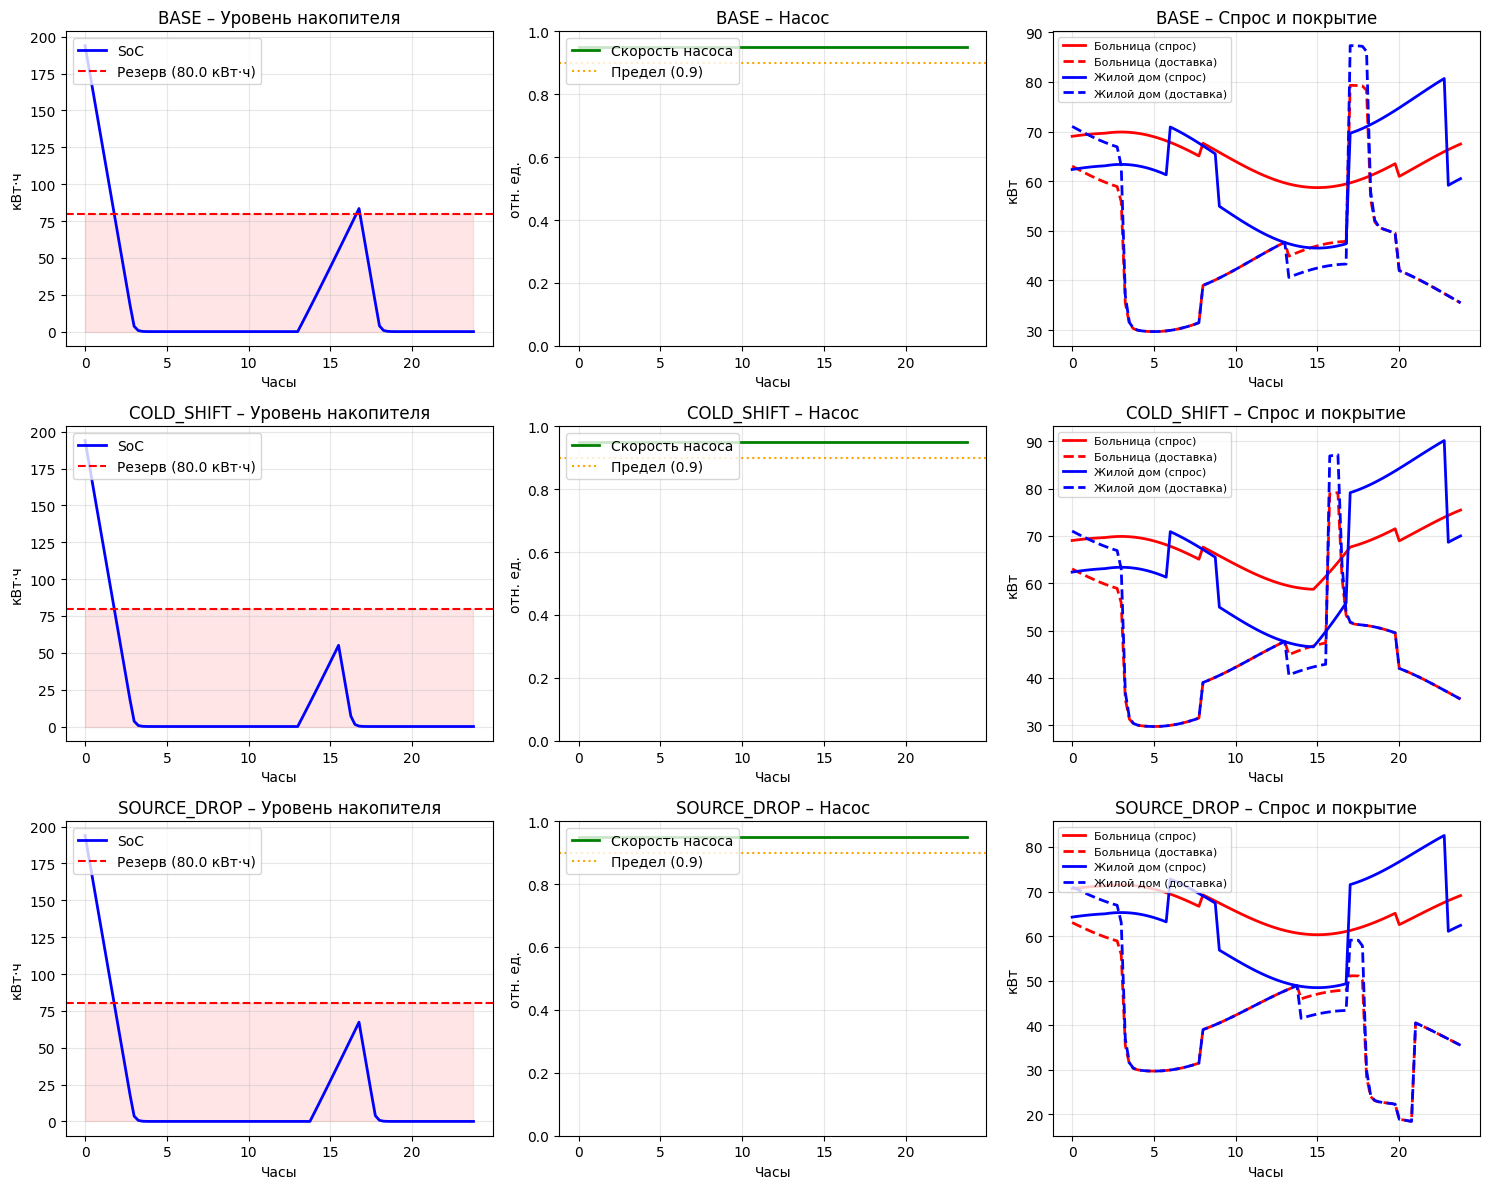

In [ ]:
import matplotlib.pyplot as plt

def run_and_collect_data(controller, scenario_name):
    inputs = build_scenario(scenario_name)
    results = []
    storage_soc = 210.0
    times = []

    for row in inputs:
        ctrl = controller(row)
        res = simulate_step(row, ctrl, storage_soc)
        storage_soc = res.storage_soc_kwh
        results.append(res)
        times.append(row.hour)

    soc_series = [r.storage_soc_kwh for r in results]
    pump_series = [r.pump_speed for r in results]
    hospital_delivered = [r.hospital_delivered_kw for r in results]
    residential_delivered = [r.residential_delivered_kw for r in results]
    hospital_demand_series = [inp.hospital_demand_kw for inp in inputs]
    residential_demand_series = [inp.residential_demand_kw for inp in inputs]

    return {
        'times': times,
        'soc': soc_series,
        'pump': pump_series,
        'hosp_del': hospital_delivered,
        'res_del': residential_delivered,
        'hosp_dem': hospital_demand_series,
        'res_dem': residential_demand_series,
    }

def plot_all_scenarios(controller, scenarios=['BASE', 'COLD_SHIFT', 'SOURCE_DROP']):
    """Строит визуализацию для всех трёх сценариев."""
    fig, axes = plt.subplots(nrows=len(scenarios), ncols=3,
                             figsize=(15, 4*len(scenarios)))
    if len(scenarios) == 1:
        axes = [axes]
    for i, scenario in enumerate(scenarios):
        data = run_and_collect_data(controller, scenario)
        t = data['times']

        ax1 = axes[i, 0] if len(scenarios) > 1 else axes[0]
        ax1.plot(t, data['soc'], 'b-', linewidth=2, label='SoC')
        ax1.axhline(y=STORAGE_RESERVE_KWH, color='r', linestyle='--',
                    label=f'Резерв ({STORAGE_RESERVE_KWH} кВт·ч)')
        ax1.fill_between(t, 0, STORAGE_RESERVE_KWH, color='red', alpha=0.1)
        ax1.set_ylabel('кВт·ч')
        ax1.set_title(f'{scenario} – Уровень накопителя')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        ax2 = axes[i, 1] if len(scenarios) > 1 else axes[1]
        ax2.plot(t, data['pump'], 'g-', linewidth=2, label='Скорость насоса')
        ax2.axhline(y=0.9, color='orange', linestyle=':', label='Предел (0.9)')
        ax2.set_ylabel('отн. ед.')
        ax2.set_ylim(0, 1)
        ax2.set_title(f'{scenario} – Насос')
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[i, 2] if len(scenarios) > 1 else axes[2]
        ax3.plot(t, data['hosp_dem'], 'r-', label='Больница (спрос)', linewidth=2)
        ax3.plot(t, data['hosp_del'], 'r--', label='Больница (доставка)', linewidth=2)
        ax3.plot(t, data['res_dem'], 'b-', label='Жилой дом (спрос)', linewidth=2)
        ax3.plot(t, data['res_del'], 'b--', label='Жилой дом (доставка)', linewidth=2)
        ax3.set_ylabel('кВт')
        ax3.set_title(f'{scenario} – Спрос и покрытие')
        ax3.legend(loc='upper left', fontsize=8)
        ax3.grid(True, alpha=0.3)

    for ax_row in axes:
        for ax in ax_row:
            ax.set_xlabel('Часы')
    plt.tight_layout()
    plt.show()

plot_all_scenarios(student_controller)